In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE_DIR = '/content/drive/MyDrive/Proyecto2_UAV'
os.makedirs(BASE_DIR, exist_ok=True)
print(f"Carpeta persistente lista en: {BASE_DIR}")

In [ ]:
import os

# Coloca tu archivo kaggle.json en esta misma carpeta antes de correr esta celda
# (Kaggle > tu perfil > Account > "Create New API Token")
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download rhammell/ships-in-satellite-imagery
!unzip -q -o ships-in-satellite-imagery.zip -d dataset/

print("Dataset descargado y descomprimido exitosamente.")


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/rhammell/ships-in-satellite-imagery
License(s): CC-BY-SA-4.0
100% 185M/185M [00:02<00:00, 90.7MB/s]

Dataset descargado y descomprimido exitosamente.


In [ ]:
import os
import random
import shutil

def obtener_grupo(nombre_archivo):
    """Identificador de escena satelital: fecha + id de escena (ignora hora exacta y coordenadas)."""
    partes = nombre_archivo.replace('.png', '').split('__')
    fecha_hora_id = partes[1].split('_')
    fecha = fecha_hora_id[0]
    escena_id = fecha_hora_id[2] if len(fecha_hora_id) >= 3 else fecha_hora_id[-1]
    return f"{fecha}_{escena_id}"

ruta_original = 'dataset/shipsnet/shipsnet'
ruta_test_ciego = 'carpeta_prueba_ciega'
os.makedirs(ruta_test_ciego, exist_ok=True)

archivos = [f for f in os.listdir(ruta_original) if f.endswith('.png')]

grupos = {}
for f in archivos:
    g = obtener_grupo(f)
    grupos.setdefault(g, []).append(f)

ids_grupo = list(grupos.keys())
random.seed(42)
random.shuffle(ids_grupo)

num_grupos_test = int(len(ids_grupo) * 0.15)
grupos_test = set(ids_grupo[:num_grupos_test])

archivos_test = [f for g in grupos_test for f in grupos[g]]

for f in archivos_test:
    shutil.move(os.path.join(ruta_original, f), os.path.join(ruta_test_ciego, f))

print(f"✅ Se movieron {len(archivos_test)} imágenes ({len(grupos_test)} escenas) a '{ruta_test_ciego}'.")
print(f"📊 Quedaron {len(archivos) - len(archivos_test)} imágenes ({len(ids_grupo) - len(grupos_test)} escenas) para entrenar.")

!zip -q -r carpeta_prueba_ciega.zip carpeta_prueba_ciega/
print("📦 Archivo 'carpeta_prueba_ciega.zip' creado con éxito.")


✅ Se movieron 572 imágenes (37 escenas) a 'carpeta_prueba_ciega'.
📊 Quedaron 3428 imágenes (210 escenas) para entrenar.
📦 Archivo 'carpeta_prueba_ciega.zip' creado con éxito.


✅ GPU detectada: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Cargando imágenes...
Total: 3428 | Escenas únicas: 210 | No barco: 2562 | Barco: 866
Pesos de clase: {0: np.float64(0.6690085870413739), 1: np.float64(1.9792147806004619)}

🚀 Iniciando Validación Cruzada...

--- Entrenando Fold 1 ---


/tmp/ipykernel_648/1543218144.py:58: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 25s 84ms/step - accuracy: 0.6079 - loss: 0.7827 - val_accuracy: 0.7411 - val_loss: 0.5476
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7078 - loss: 0.5992 - val_accuracy: 0.8156 - val_loss: 0.4203
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7772 - loss: 0.4750 - val_accuracy: 0.8457 - val_loss: 0.3609
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.7926 - loss: 0.4481 - val_accuracy: 0.8475 - val_loss: 0.3511
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8265 - loss: 0.3781 - val_accuracy: 0.8777 - val_loss: 0.3113
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8579 - loss: 0.3318 - val_accuracy: 0.8918 - val_loss: 0.2663
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8747 - loss: 0.2883 - val_accuracy: 0.8848 - val_loss: 0.2724
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy

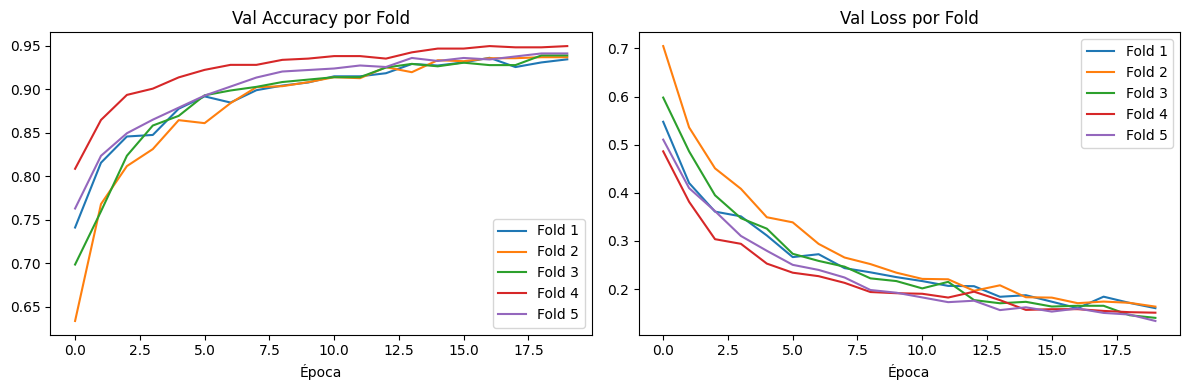


Entrenamiento final: 2822 imágenes | Validación: 606 imágenes

🏁 Modelo final - Fase 1 (base congelada)...


/tmp/ipykernel_648/1543218144.py:58: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')


Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.6106 - loss: 0.8050 - val_accuracy: 0.7921 - val_loss: 0.4834
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7261 - loss: 0.5734 - val_accuracy: 0.8317 - val_loss: 0.3998
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.7892 - loss: 0.4516 - val_accuracy: 0.8647 - val_loss: 0.3356
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8303 - loss: 0.3959 - val_accuracy: 0.8746 - val_loss: 0.3144
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.8501 - loss: 0.3387 - val_accuracy: 0.8861 - val_loss: 0.2802
Epoch 6/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8607 - loss: 0.3211 - val_accuracy: 0.9026 - val_loss: 0.2579
Epoch 7/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.8763 - loss: 0.3049 - val_accuracy: 0.9010 - val_loss: 0.2570
Epoch 8/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8855 - loss: 0.2689 - val_accuracy: 0.9109 - v


📊 Accuracy del modelo final en su set de validación: 92.24%
💾 Modelo final guardado en 'mejor_modelo_barcos.h5'.


In [ ]:
import os
import cv2
import json

try:
    BASE_DIR
except NameError:
    BASE_DIR = '/content/drive/MyDrive/Proyecto2_UAV'
    os.makedirs(BASE_DIR, exist_ok=True)

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, applications
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 80  # resolución nativa del dataset (subir a 160 solo agregaba borrosidad, no información real)

gpu_devices = tf.config.list_physical_devices('GPU')
print(f"✅ GPU detectada: {gpu_devices[0]}" if gpu_devices else "❌ No se detectó GPU.")

# ------------------------------------------------------------------
# 1. AGRUPACIÓN POR ESCENA (evita fuga de datos)
# ------------------------------------------------------------------
def obtener_grupo(nombre_archivo):
    partes = nombre_archivo.replace('.png', '').split('__')
    fecha_hora_id = partes[1].split('_')
    fecha = fecha_hora_id[0]
    escena_id = fecha_hora_id[2] if len(fecha_hora_id) >= 3 else fecha_hora_id[-1]
    return f"{fecha}_{escena_id}"

# ------------------------------------------------------------------
# 2. CARGA (sin normalizar -> lo hace la capa Rescaling dentro del modelo)
# ------------------------------------------------------------------
def load_data(folder_path):
    images, labels, grupos = [], [], []
    print("Cargando imágenes...")
    for filename in sorted(os.listdir(folder_path)):
        if filename.endswith(".png"):
            label = int(filename[0])
            img = cv2.imread(os.path.join(folder_path, filename))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)).astype('float32')
            images.append(img)
            labels.append(label)
            grupos.append(obtener_grupo(filename))
    return np.array(images), np.array(labels), np.array(grupos)

X, y, grupos = load_data('dataset/shipsnet/shipsnet')
print(f"Total: {X.shape[0]} | Escenas únicas: {len(set(grupos))} | No barco: {np.sum(y==0)} | Barco: {np.sum(y==1)}")

pesos = compute_class_weight('balanced', classes=np.array([0, 1]), y=y)
class_weight = {0: pesos[0], 1: pesos[1]}
print(f"Pesos de clase: {class_weight}")

# ------------------------------------------------------------------
# 3. ARQUITECTURA
# ------------------------------------------------------------------
def create_model():
    base_model = applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
    base_model.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.RandomFlip("horizontal_and_vertical")(inputs)
    x = layers.RandomRotation(0.15)(x)
    x = layers.RandomZoom(0.15)(x)
    x = layers.RandomContrast(0.15)(x)
    x = layers.Rescaling(scale=1./127.5, offset=-1.0)(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model, base_model

# ------------------------------------------------------------------
# 4. VALIDACIÓN CRUZADA AGRUPADA (mide generalización real, para E2/E3)
# ------------------------------------------------------------------
k_folds = 5
sgkf = StratifiedGroupKFold(n_splits=k_folds, shuffle=True, random_state=SEED)
accuracies = []
histories = []

print("\n🚀 Iniciando Validación Cruzada...")
for fold_no, (train_idx, val_idx) in enumerate(sgkf.split(X, y, groups=grupos), start=1):
    assert len(set(grupos[train_idx]) & set(grupos[val_idx])) == 0, "¡Fuga de datos!"

    print(f"\n--- Entrenando Fold {fold_no} ---")
    tf.keras.backend.clear_session()

    model, _ = create_model()
    early_stopping = callbacks.EarlyStopping(monitor='val_accuracy', mode='max', patience=6, restore_best_weights=True)

    history = model.fit(
        X[train_idx], y[train_idx],
        validation_data=(X[val_idx], y[val_idx]),
        epochs=20, batch_size=32,
        class_weight=class_weight,
        callbacks=[early_stopping], verbose=1
    )
    histories.append(history)

    acc = model.evaluate(X[val_idx], y[val_idx], verbose=0)[1] * 100
    print(f"✅ Accuracy del Fold {fold_no}: {acc:.2f}%")
    accuracies.append(acc)

print("\n" + "="*40)
print(f"📊 Accuracy Promedio (Validación Cruzada): {np.mean(accuracies):.2f}% (+/- {np.std(accuracies):.2f}%)")
print("="*40)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, h in enumerate(histories, start=1):
    axes[0].plot(h.history['val_accuracy'], label=f'Fold {i}')
    axes[1].plot(h.history['val_loss'], label=f'Fold {i}')
axes[0].set_title('Val Accuracy por Fold'); axes[0].set_xlabel('Época'); axes[0].legend()
axes[1].set_title('Val Loss por Fold'); axes[1].set_xlabel('Época'); axes[1].legend()
plt.tight_layout()
plt.savefig('curvas_validacion_cruzada.png', dpi=150)
plt.show()

# ------------------------------------------------------------------
# 5. MODELO FINAL: split train/val por escena (nunca toca el test ciego)
# ------------------------------------------------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(gss.split(X, y, groups=grupos))
X_tr, X_val, y_tr, y_val = X[train_idx], X[val_idx], y[train_idx], y[val_idx]
print(f"\nEntrenamiento final: {len(X_tr)} imágenes | Validación: {len(X_val)} imágenes")

# --- Fase 1: cabeza nueva, base congelada ---
print("\n🏁 Modelo final - Fase 1 (base congelada)...")
tf.keras.backend.clear_session()
modelo_final, base_final = create_model()

es_fase1 = callbacks.EarlyStopping(monitor='val_accuracy', mode='max', patience=6, restore_best_weights=True)
modelo_final.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                  epochs=20, batch_size=32, class_weight=class_weight,
                  callbacks=[es_fase1], verbose=1)

# --- Fase 2: fine-tuning PARCIAL (solo el último 40% de capas) ---
# Descongelar el 100% con pocos datos de entrenamiento sobreajusta y empeora
# la generalización (esto fue justo lo que pasó en el intento anterior).
print("\n🔧 Modelo final - Fase 2 (fine-tuning parcial, últimas capas)...")
base_final.trainable = True
capas_congelar = int(len(base_final.layers) * 0.6)
for layer in base_final.layers[:capas_congelar]:
    layer.trainable = False

modelo_final.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                      loss='binary_crossentropy', metrics=['accuracy'])

es_fase2 = callbacks.EarlyStopping(monitor='val_accuracy', mode='max', patience=6, restore_best_weights=True)
reduce_lr_fase2 = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7)

modelo_final.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                  epochs=20, batch_size=32, class_weight=class_weight,
                  callbacks=[es_fase2, reduce_lr_fase2], verbose=1)

val_acc_final = modelo_final.evaluate(X_val, y_val, verbose=0)[1] * 100
print(f"\n📊 Accuracy del modelo final en su set de validación: {val_acc_final:.2f}%")

# Guardamos umbral fijo en 0.5 (la búsqueda de "umbral óptimo" del intento
# anterior se sobreajustaba al set de validación y no generalizaba bien)
with open(f'{BASE_DIR}/umbral_optimo.json', 'w') as f:
    json.dump({'umbral': 0.5, 'img_size': IMG_SIZE}, f)

modelo_final.save(f'{BASE_DIR}/mejor_modelo_barcos.h5')
print(f"💾 Modelo final guardado en '{BASE_DIR}/mejor_modelo_barcos.h5' (persistente en Drive).")


In [ ]:
!pip install -q gradio seaborn scikit-learn


In [ ]:
import gradio as gr
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from tensorflow.keras.models import load_model
import json

# 0. Cargar el umbral óptimo calculado durante el entrenamiento
try:
    BASE_DIR
except NameError:
    BASE_DIR = '/content/drive/MyDrive/Proyecto2_UAV'

try:
    with open(f'{BASE_DIR}/umbral_optimo.json', 'r') as f:
        _config = json.load(f)
    UMBRAL = _config['umbral']
    IMG_SIZE = _config['img_size']
    print(f"✅ Umbral óptimo cargado: {UMBRAL:.2f} | Tamaño de imagen: {IMG_SIZE}")
except Exception as e:
    print(f"⚠️ No se encontró umbral_optimo.json en Drive, usando valores por defecto. ({e})")
    UMBRAL = 0.5
    IMG_SIZE = 80

# 1. Cargar el modelo DESDE DRIVE (persistente entre sesiones)
try:
    modelo = load_model(f'{BASE_DIR}/mejor_modelo_barcos.h5')
    print(f"✅ Modelo cargado exitosamente desde {BASE_DIR} para la UI.")
except Exception as e:
    print(f"❌ Error al cargar el modelo: {e}")

# Función auxiliar para predecir una sola imagen
def predecir_imagen(ruta_img):
    img = cv2.imread(ruta_img)
    if img is None:
        return 0
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_CUBIC).astype('float32')

    # Test-Time Augmentation: promediamos la predicción de la imagen original
    # y sus versiones espejadas -> más robusto en casos límite
    variantes = [img, cv2.flip(img, 1), cv2.flip(img, 0), cv2.flip(img, -1)]
    batch = np.stack(variantes, axis=0)
    preds = modelo.predict(batch, verbose=0).ravel()
    pred_promedio = preds.mean()

    return 1 if pred_promedio > UMBRAL else 0

# Función auxiliar para calcular métricas y gráficas
def calcular_metricas_y_graficar(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred, zero_division=0) * 100
    rec = recall_score(y_true, y_pred, zero_division=0) * 100

    texto_metricas = f"### 📊 Resultados de la Evaluación en Vivo (Evidencia E4)\n"
    texto_metricas += f"**Total de imágenes evaluadas:** {len(y_true)}\n\n"
    texto_metricas += f"- **Accuracy (Exactitud):** `{acc:.2f}%`\n"
    texto_metricas += f"- **Precision (Precisión):** `{prec:.2f}%`\n"
    texto_metricas += f"- **Recall (Exhaustividad):** `{rec:.2f}%`\n\n"

    if acc >= 98.0:
        texto_metricas += "✅ **¡Nivel N5 alcanzado! Accuracy superior al 98%.**"
    elif acc >= 96.0:
        texto_metricas += "⚠️ **Nivel N4 alcanzado.**"
    else:
        texto_metricas += "❌ **Penalización aplicable (Accuracy < 98%).**"

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Barco (0)', 'Barco (1)'],
                yticklabels=['No Barco (0)', 'Barco (1)'])
    plt.ylabel('Etiqueta Real')
    plt.xlabel('Predicción del Modelo')
    plt.title("Matriz de Confusión")
    plt.tight_layout()

    return texto_metricas, fig

# Genera el HTML de una barra de progreso propia (no depende del render nativo de Gradio)
def barra_html(pct):
    pct = max(0, min(100, pct))
    return f"""
    <div style="width:100%; background:#e5e7eb; border-radius:12px; overflow:hidden; height:28px; box-shadow: inset 0 1px 3px rgba(0,0,0,0.15);">
        <div style="width:{pct}%; height:100%; background:linear-gradient(90deg,#2563eb,#06b6d4);
                    transition: width 0.25s ease; display:flex; align-items:center; justify-content:flex-end; padding-right:8px;">
            <span style="color:white; font-weight:600; font-size:13px;">{pct}%</span>
        </div>
    </div>
    """

# --- LÓGICA PRINCIPAL (ahora es un GENERADOR: usa yield para refrescar la UI en cada paso) ---

def iniciar_evaluacion(archivos, modo):
    if not archivos:
        yield [gr.update(visible=True), gr.update(visible=False), gr.update(visible=False), gr.update(visible=False),
               barra_html(0), "", None, "", "", None, {}]
        return

    rutas = [f.name if hasattr(f, 'name') else f for f in archivos]
    rutas = [r for r in rutas if r.lower().endswith(('.png', '.jpg', '.jpeg'))]
    total_rutas = len(rutas)

    if not rutas:
        yield [gr.update(visible=True), gr.update(visible=False), gr.update(visible=False), gr.update(visible=False),
               barra_html(0), "", None, "⚠️ No hay imágenes válidas en la carpeta.", "", None, {}]
        return

    # ----------------------------------------------------
    # MODO 1: AUTOMÁTICA (con barra de progreso propia)
    # ----------------------------------------------------
    if modo == "Automática (Leer etiqueta del nombre del archivo)":
        y_true, y_pred = [], []

        # Cambiamos a la pantalla de "procesando"
        yield [gr.update(visible=False), gr.update(visible=True), gr.update(visible=False), gr.update(visible=False),
               barra_html(0), f"Procesando 0 de {total_rutas} imágenes...", None, "", "", None, {}]

        paso_actualizacion = max(1, total_rutas // 100)  # evita saturar la UI en datasets grandes

        for i, ruta in enumerate(rutas, start=1):
            nombre_archivo = os.path.basename(ruta)
            try:
                etiqueta = int(nombre_archivo[0])
                if etiqueta in [0, 1]:
                    y_true.append(etiqueta)
                    y_pred.append(predecir_imagen(ruta))
            except ValueError:
                pass

            if i % paso_actualizacion == 0 or i == total_rutas:
                pct = int((i / total_rutas) * 100)
                yield [gr.update(), gr.update(), gr.update(), gr.update(),
                       barra_html(pct), f"Procesando {i} de {total_rutas} imágenes ({pct}%)",
                       None, "", "", None, {}]

        if len(y_true) == 0:
            yield [gr.update(visible=True), gr.update(visible=False), gr.update(visible=False), gr.update(visible=False),
                   barra_html(0), "", None, "⚠️ Las imágenes no tienen el formato 1_... o 0_... para modo automático.", "", None, {}]
            return

        txt_res, fig_res = calcular_metricas_y_graficar(y_true, y_pred)
        yield [gr.update(visible=False), gr.update(visible=False), gr.update(visible=False), gr.update(visible=True),
               barra_html(100), "¡Listo! ✅", None, "", txt_res, fig_res, {}]

    # ----------------------------------------------------
    # MODO 2: MANUAL INTERACTIVO
    # ----------------------------------------------------
    else:
        estado = {"rutas": rutas, "idx": 0, "y_true": [], "y_pred": []}
        primera_ruta = rutas[0]
        pred_modelo = predecir_imagen(primera_ruta)
        txt_info = f"### Imagen 1 de {total_rutas}\n\n🤖 El modelo predice que es: **{'🚢 UN BARCO' if pred_modelo == 1 else '🌊 NO ES BARCO'}**"

        yield [gr.update(visible=False), gr.update(visible=False), gr.update(visible=True), gr.update(visible=False),
               barra_html(0), "", primera_ruta, txt_info, "", None, estado]

def registrar_respuesta(es_barco, estado):
    estado["y_true"].append(es_barco)
    ruta_actual = estado["rutas"][estado["idx"]]
    estado["y_pred"].append(predecir_imagen(ruta_actual))

    estado["idx"] += 1

    if estado["idx"] < len(estado["rutas"]):
        siguiente_ruta = estado["rutas"][estado["idx"]]
        pred_modelo = predecir_imagen(siguiente_ruta)
        txt_info = f"### Imagen {estado['idx'] + 1} de {len(estado['rutas'])}\n\n🤖 El modelo predice que es: **{'🚢 UN BARCO' if pred_modelo == 1 else '🌊 NO ES BARCO'}**"
        return [gr.update(visible=True), gr.update(visible=False), siguiente_ruta, txt_info, "", None, estado]

    else:
        txt_res, fig_res = calcular_metricas_y_graficar(estado["y_true"], estado["y_pred"])
        return [gr.update(visible=False), gr.update(visible=True), None, "", txt_res, fig_res, estado]

def reiniciar_app():
    return [gr.update(visible=True), gr.update(visible=False), gr.update(visible=False), gr.update(visible=False),
            None, "", "", None, {}]

# --- CONSTRUCCIÓN DE LA PÁGINA (rediseñada) ---

css_custom = """
#titulo_app {text-align: center; margin-bottom: 0px;}
#subtitulo_app {text-align: center; color: #6b7280; margin-top: 0px;}
.gradio-container {max-width: 900px !important; margin: auto !important;}
"""

with gr.Blocks(title="Sistema de Inferencia IA - Proyecto 2", theme=gr.themes.Soft(primary_hue="blue", secondary_hue="cyan"), css=css_custom) as interfaz:
    estado = gr.State()

    gr.Markdown("# 🚢 Clasificador Binario de Embarcaciones", elem_id="titulo_app")
    gr.Markdown("Sistema de inferencia sobre imágenes UAV / Dron — Evidencias ABET: E1, E3, E4", elem_id="subtitulo_app")

    with gr.Column(visible=True) as pantalla_carga:
        with gr.Group():
            radio_modo = gr.Radio(
                choices=["Automática (Leer etiqueta del nombre del archivo)", "Manual Interactivo (Evaluar imagen por imagen)"],
                value="Automática (Leer etiqueta del nombre del archivo)",
                label="⚙️ Método de Validación y Etiquetado en Vivo"
            )
            input_carpeta = gr.File(file_count="directory", label="📁 Carga la carpeta de imágenes de prueba (Test dataset)")
            btn_iniciar = gr.Button("🚀 Iniciar Inferencias", variant="primary", size="lg")

    with gr.Column(visible=False) as pantalla_progreso:
        gr.Markdown("## ⏳ Procesando imágenes...")
        html_barra = gr.HTML(barra_html(0))
        txt_contador = gr.Markdown("")

    with gr.Column(visible=False) as pantalla_interaccion:
        txt_estado = gr.Markdown()
        visor_imagen = gr.Image(type="filepath", width=400)
        gr.Markdown("### Supervisión de Etiquetado: ¿Cuál es la realidad de esta imagen?")
        with gr.Row():
            btn_si = gr.Button("✅ Es un Barco (1)", variant="primary")
            btn_no = gr.Button("❌ NO es un Barco (0)", variant="stop")

    with gr.Column(visible=False) as pantalla_resultados:
        gr.Markdown("## 🎉 Pipeline de Validación Terminado")
        txt_resultados = gr.Markdown()
        grafico_cm = gr.Plot()
        btn_volver = gr.Button("🔄 Evaluar otra carpeta")

    btn_iniciar.click(
        iniciar_evaluacion,
        inputs=[input_carpeta, radio_modo],
        outputs=[pantalla_carga, pantalla_progreso, pantalla_interaccion, pantalla_resultados,
                  html_barra, txt_contador, visor_imagen, txt_estado, txt_resultados, grafico_cm, estado]
    )

    btn_si.click(
        lambda s: registrar_respuesta(1, s), inputs=[estado],
        outputs=[pantalla_interaccion, pantalla_resultados, visor_imagen, txt_estado, txt_resultados, grafico_cm, estado]
    )

    btn_no.click(
        lambda s: registrar_respuesta(0, s), inputs=[estado],
        outputs=[pantalla_interaccion, pantalla_resultados, visor_imagen, txt_estado, txt_resultados, grafico_cm, estado]
    )

    btn_volver.click(
        reiniciar_app, inputs=[],
        outputs=[pantalla_carga, pantalla_progreso, pantalla_interaccion, pantalla_resultados,
                  input_carpeta, txt_estado, txt_resultados, grafico_cm, estado]
    )

# queue() es obligatorio para que los "yield" se vean en vivo en la interfaz
interfaz.queue().launch(share=True, debug=True)